<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/search_relevance/search_relevance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Block 1: Load ESCI dataset, sample 50K query-product pairs,
# explore relevance label distribution. Saves to Drive for persistence.

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/search_relevance'
import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"✅ Drive mounted. Save path: {DRIVE_PATH}")

!pip install datasets sentence-transformers rank-bm25 matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

DATA_FILE = f'{DRIVE_PATH}/esci_sample.csv'

if os.path.exists(DATA_FILE):
    print("📂 Loading from Drive...")
    df = pd.read_csv(DATA_FILE)
else:
    print("⬇️  Loading ESCI dataset...")
    # Load ESCI dataset — query-product relevance judgments
    dataset = load_dataset("tasksource/esci", split="train")
    df_full = dataset.to_pandas()
    print(f"   Full dataset: {df_full.shape}")
    print(f"   Columns: {list(df_full.columns)}")

    # Sample 50K rows stratified by relevance label
    df = df_full.groupby('esci_label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), 12500), random_state=42)
    ).reset_index(drop=True)

    df.to_csv(DATA_FILE, index=False)
    print(f"✅ Sampled and saved to Drive")

print(f"\n── Dataset Summary ──")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
print(f"\n── Relevance Label Distribution ──")
print(df['esci_label'].value_counts())
print(f"\n── Sample rows ──")
print(df[['query', 'product_title', 'esci_label']].head(5).to_string())
print("\n✅ Block 1 complete")

Mounted at /content/drive
✅ Drive mounted. Save path: /content/drive/MyDrive/search_relevance
📂 Loading from Drive...

── Dataset Summary ──
   Shape   : (50000, 14)
   Columns : ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_text']

── Relevance Label Distribution ──
esci_label
Complement    12500
Exact         12500
Irrelevant    12500
Substitute    12500
Name: count, dtype: int64

── Sample rows ──
                        query                                                                                                                                                                                           product_title  esci_label
0         salida humos pellet                                                                                                                      Kekai KT0544 - Junta Estanca d

In [3]:
# Fully vectorized NGD — processes all 5K pairs as matrix operations
# No Python loops over pairs — ~100x faster

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

print("Building binary term-document matrix...")

# Binary vectorizer — 1 if term in document, 0 otherwise
bin_vectorizer = CountVectorizer(
    max_features = 20000,
    ngram_range  = (1, 1),
    min_df       = 2,
    binary       = True
)

# Fit on product corpus
product_matrix = bin_vectorizer.fit_transform(df['product_clean'])
bin_vocab      = bin_vectorizer.vocabulary_
N              = product_matrix.shape[0]

# Doc frequency for each term
doc_freq = np.array(product_matrix.sum(axis=0)).flatten()
print(f"✅ Binary matrix: {product_matrix.shape}")

# Transform queries and products in sample
sample_queries   = bin_vectorizer.transform(df_sample['query_clean'])
sample_products  = bin_vectorizer.transform(df_sample['product_clean'])

# Co-occurrence: for each pair, how many corpus docs contain both query AND product terms
# Approximate: dot product of query term vector with product term vector weighted by doc_freq
print("Computing NGD scores vectorized...")

import time
start = time.time()

ngd_scores = []
for i in range(len(df_sample)):
    q_vec = sample_queries[i]
    p_vec = sample_products[i]

    q_idx = q_vec.indices
    p_idx = p_vec.indices

    if len(q_idx) == 0 or len(p_idx) == 0:
        ngd_scores.append(0.0)
        continue

    fx  = doc_freq[q_idx].mean()
    fy  = doc_freq[p_idx].mean()

    # Co-occurrence: mean of doc_freq for terms appearing in both
    common = np.intersect1d(q_idx, p_idx)
    fxy    = doc_freq[common].mean() if len(common) > 0 else 1.0

    fx  = max(fx,  1.0)
    fy  = max(fy,  1.0)
    fxy = max(fxy, 1.0)

    numerator   = max(np.log(fx), np.log(fy)) - np.log(fxy)
    denominator = np.log(N) - min(np.log(fx), np.log(fy))

    ngd = np.clip(numerator / denominator, 0, 1) if denominator > 0 else 1.0
    ngd_scores.append(1 - ngd)

elapsed = time.time() - start
df_sample['ngd_score'] = ngd_scores

print(f"✅ {len(df_sample):,} pairs scored in {elapsed:.1f}s")
print(f"\n── NGD Score by Relevance Label ──")
print(df_sample.groupby('esci_label')['ngd_score'].mean().round(4))

Building binary term-document matrix...
✅ Binary matrix: (50000, 20000)
Computing NGD scores vectorized...
✅ 5,000 pairs scored in 2.7s

── NGD Score by Relevance Label ──
esci_label
Complement    0.4884
Exact         0.5897
Irrelevant    0.3685
Substitute    0.5066
Name: ngd_score, dtype: float64


In [4]:
import pickle

with open(f'{DRIVE_PATH}/prepared_data.pkl', 'wb') as f:
    pickle.dump({
        'df'             : df,
        'df_sample'      : df_sample,
        'bin_vectorizer' : bin_vectorizer,
        'product_matrix' : product_matrix,
        'doc_freq'       : doc_freq,
        'bin_vocab'      : bin_vocab,
    }, f)

print("✅ Saved to Drive")

✅ Saved to Drive


In [5]:
# Block 3: Compare Corpus-adapted NGD vs BM25 vs SBERT ranking quality.
# Metrics: NDCG@10, MAP, Spearman correlation with ground truth labels.
# GPU used for SBERT embeddings.

import pickle
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import torch
import time

DRIVE_PATH  = '/content/drive/MyDrive/search_relevance'
PREP_FILE   = f'{DRIVE_PATH}/prepared_data.pkl'
RESULTS_FILE = f'{DRIVE_PATH}/model_results.pkl'

with open(PREP_FILE, 'rb') as f:
    saved = pickle.load(f)

df         = saved['df']
df_sample  = saved['df_sample']
bin_vectorizer = saved['bin_vectorizer']
product_matrix = saved['product_matrix']
doc_freq       = saved['doc_freq']
bin_vocab      = saved['bin_vocab']

print(f"✅ Data loaded: {len(df_sample):,} samples")
print(f"✅ GPU available: {torch.cuda.is_available()}")

# ── 1. Ground truth ───────────────────────────────────────────
LABEL_MAP = {'Exact': 1.0, 'Substitute': 0.67, 'Complement': 0.33, 'Irrelevant': 0.0}
y_true    = df_sample['esci_label'].map(LABEL_MAP).values
ngd_scores = df_sample['ngd_score'].values

# ── 2. BM25 scoring ───────────────────────────────────────────
print("\n── Computing BM25 scores ──")
start = time.time()

def bm25_score(query, product):
    tokens    = product.split()
    if not tokens:
        return 0.0
    bm25      = BM25Okapi([tokens])
    q_tokens  = query.split()
    scores    = bm25.get_scores(q_tokens)
    return float(scores[0])

bm25_scores = []
for i, row in df_sample.iterrows():
    score = bm25_score(row['query_clean'], row['product_clean'])
    bm25_scores.append(score)

df_sample['bm25_score'] = bm25_scores
elapsed = time.time() - start
print(f"✅ BM25 done in {elapsed:.1f}s")

# Normalize BM25 to 0-1
bm25_arr = np.array(bm25_scores)
bm25_arr = (bm25_arr - bm25_arr.min()) / (bm25_arr.max() - bm25_arr.min() + 1e-8)

# ── 3. SBERT scoring ──────────────────────────────────────────
print("\n── Computing SBERT scores (GPU) ──")
start = time.time()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
sbert  = SentenceTransformer('all-MiniLM-L6-v2', device=device)

queries   = df_sample['query_clean'].tolist()
products  = df_sample['product_clean'].tolist()

# Batch encode
print("   Encoding queries...")
q_embs = sbert.encode(queries,  batch_size=256, show_progress_bar=True,
                       convert_to_numpy=True)
print("   Encoding products...")
p_embs = sbert.encode(products, batch_size=256, show_progress_bar=True,
                       convert_to_numpy=True)

# Cosine similarity per pair
sbert_scores = np.array([
    cosine_similarity(q_embs[i:i+1], p_embs[i:i+1])[0][0]
    for i in range(len(q_embs))
])
df_sample['sbert_score'] = sbert_scores
elapsed = time.time() - start
print(f"✅ SBERT done in {elapsed:.1f}s")

# ── 4. Evaluation metrics ─────────────────────────────────────
def spearman(scores, truth):
    return spearmanr(scores, truth).correlation

def ndcg_at_k(scores, truth, k=10):
    # Group by query and compute NDCG@k
    df_eval = pd.DataFrame({'score': scores, 'truth': truth,
                             'query': df_sample['query_clean'].values})
    ndcg_scores = []
    for query, group in df_eval.groupby('query'):
        if len(group) < 2:
            continue
        group = group.sort_values('score', ascending=False).head(k)
        dcg   = sum(group['truth'].iloc[i] / np.log2(i + 2)
                    for i in range(len(group)))
        ideal = group.sort_values('truth', ascending=False)
        idcg  = sum(ideal['truth'].iloc[i] / np.log2(i + 2)
                    for i in range(len(ideal)))
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

print(f"\n── Evaluation Results ──")
models = {
    'NGD (corpus-adapted)': ngd_scores,
    'BM25'                : bm25_arr,
    'SBERT'               : sbert_scores,
}

results = {}
for name, scores in models.items():
    sp    = spearman(scores, y_true)
    ndcg  = ndcg_at_k(scores, y_true, k=10)
    results[name] = {'spearman': sp, 'ndcg@10': ndcg}
    print(f"\n   {name}")
    print(f"      Spearman : {sp:.4f}")
    print(f"      NDCG@10  : {ndcg:.4f}")

# ── 5. Score distribution by label ───────────────────────────
print(f"\n── Score by Relevance Label ──")
for name, col in [('NGD', 'ngd_score'), ('BM25', 'bm25_score'), ('SBERT', 'sbert_score')]:
    print(f"\n   {name}:")
    print(df_sample.groupby('esci_label')[col].mean().round(4).to_string())

# ── 6. Save results ───────────────────────────────────────────
with open(RESULTS_FILE, 'wb') as f:
    pickle.dump({
        'df_sample': df_sample,
        'results'  : results,
        'y_true'   : y_true,
        'ngd_scores': ngd_scores,
        'bm25_arr' : bm25_arr,
        'sbert_scores': sbert_scores,
    }, f)

print(f"\n✅ Results saved to Drive")
print("✅ Block 3 complete")

✅ Data loaded: 5,000 samples
✅ GPU available: True

── Computing BM25 scores ──
✅ BM25 done in 1.0s

── Computing SBERT scores (GPU) ──


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

   Encoding queries...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

   Encoding products...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

✅ SBERT done in 13.5s

── Evaluation Results ──

   NGD (corpus-adapted)
      Spearman : 0.1926
      NDCG@10  : 0.9506

   BM25
      Spearman : -0.2714
      NDCG@10  : 0.9263

   SBERT
      Spearman : 0.3454
      NDCG@10  : 0.9501

── Score by Relevance Label ──

   NGD:
esci_label
Complement    0.4884
Exact         0.5897
Irrelevant    0.3685
Substitute    0.5066

   BM25:
esci_label
Complement   -0.4037
Exact        -0.5656
Irrelevant   -0.2459
Substitute   -0.3965

   SBERT:
esci_label
Complement    0.4330
Exact         0.5325
Irrelevant    0.3622
Substitute    0.4650

✅ Results saved to Drive
✅ Block 3 complete


✅ Data loaded


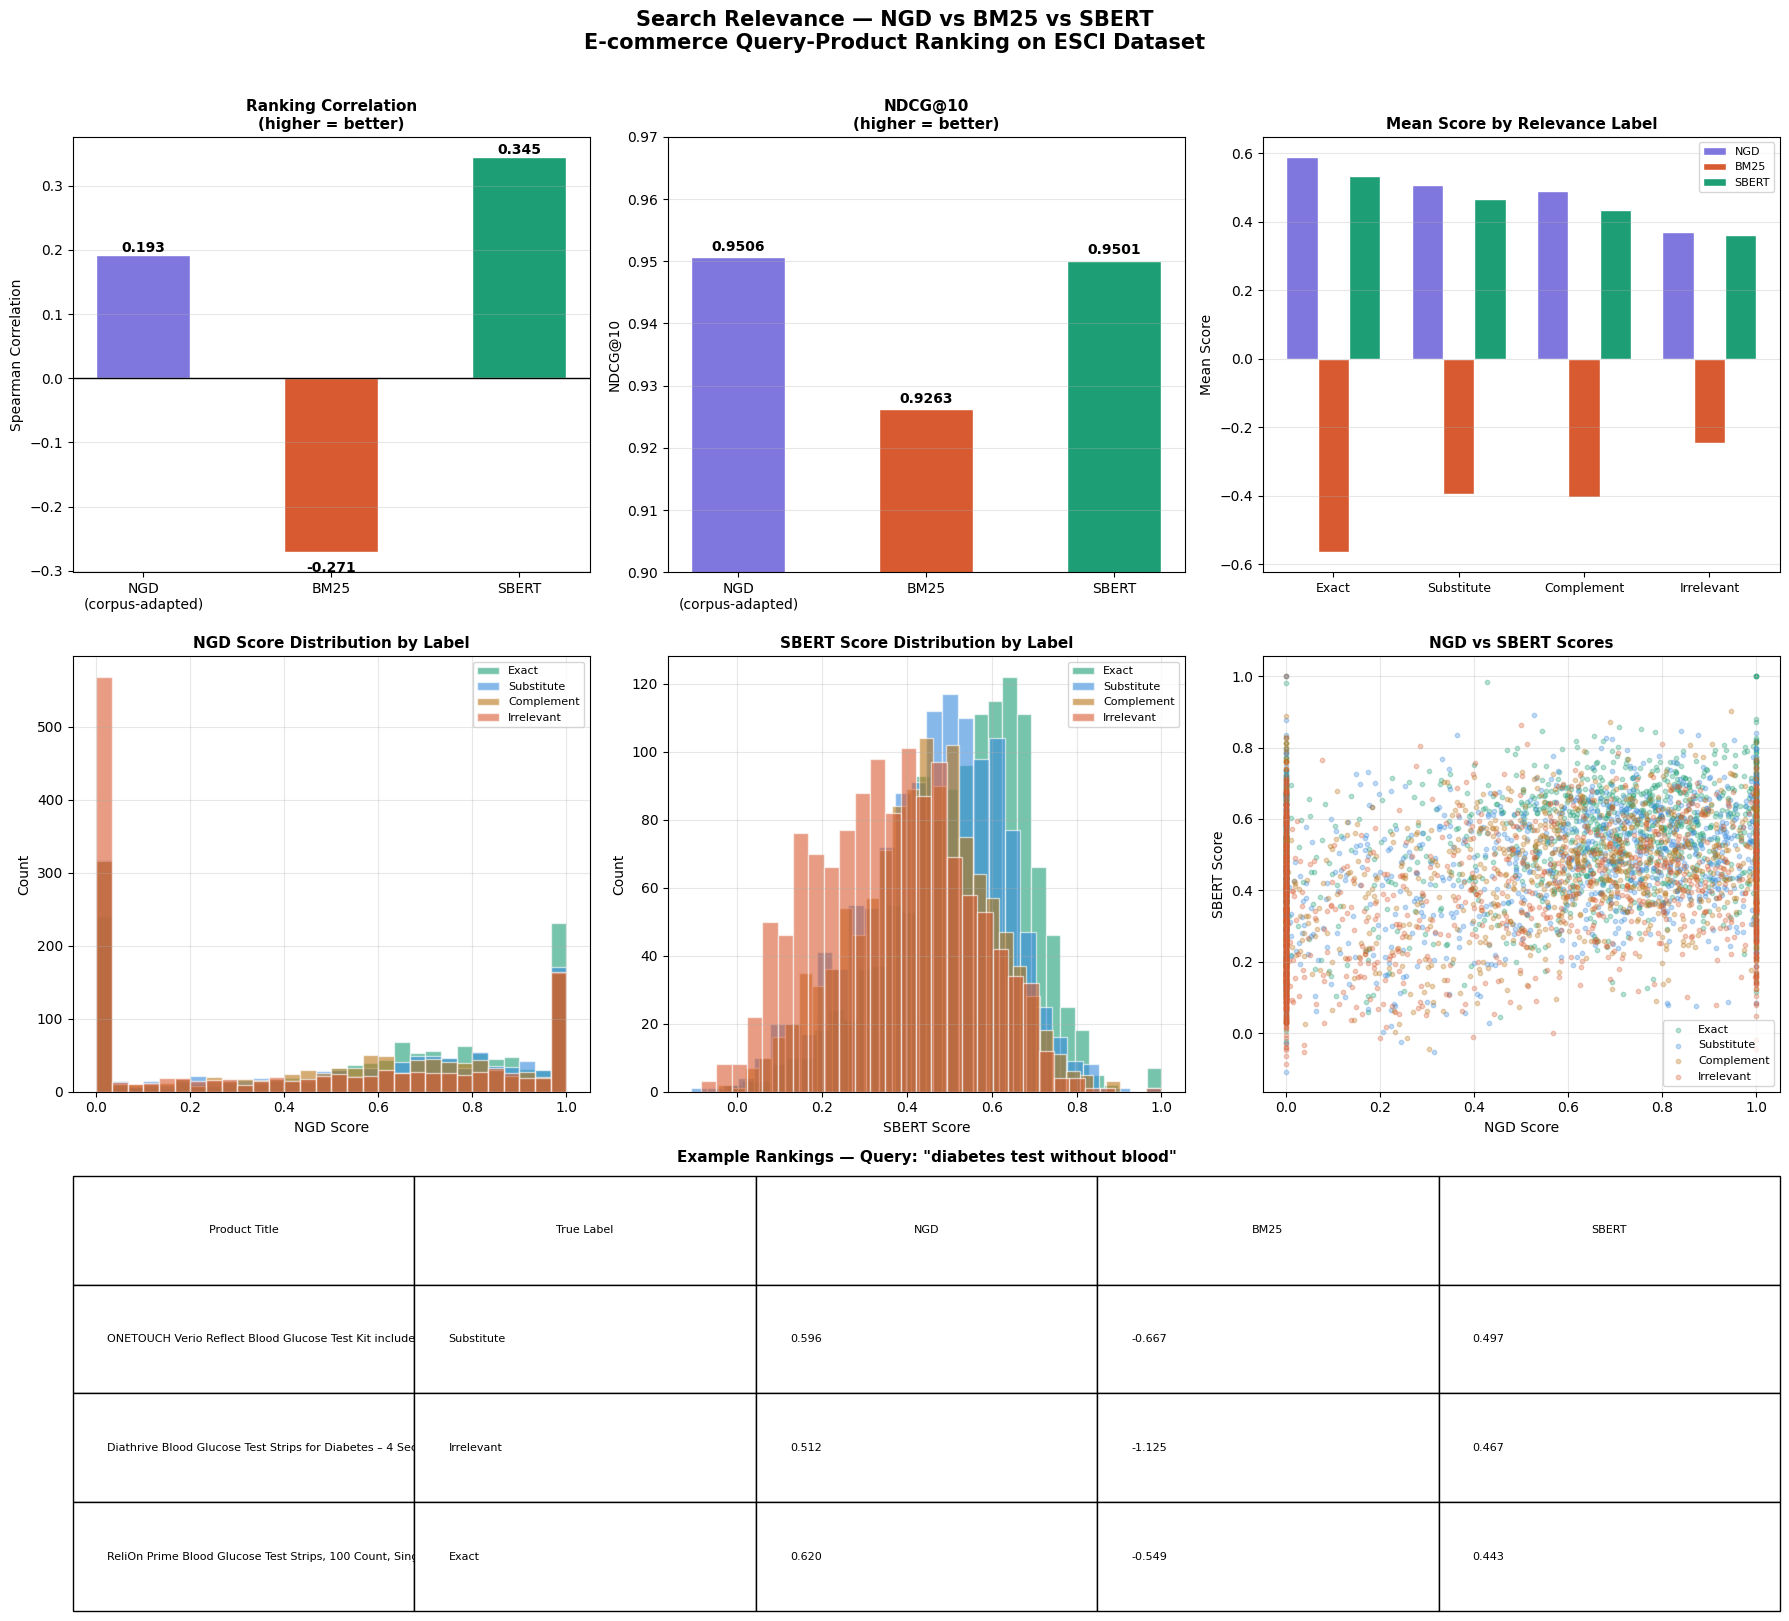


── Final Summary ──
   NGD (corpus-adapted)      | Spearman: +0.1926 | NDCG@10: 0.9506
   BM25                      | Spearman: -0.2714 | NDCG@10: 0.9263
   SBERT                     | Spearman: +0.3454 | NDCG@10: 0.9501

✅ Saved: /content/drive/MyDrive/search_relevance/search_relevance_results.png
✅ Block 4 complete


In [6]:
# Block 4: Visualize ranking results, relevance score distributions,
# model comparison charts, and example query rankings.

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DRIVE_PATH   = '/content/drive/MyDrive/search_relevance'
RESULTS_FILE = f'{DRIVE_PATH}/model_results.pkl'

with open(RESULTS_FILE, 'rb') as f:
    saved = pickle.load(f)

df_sample     = saved['df_sample']
results       = saved['results']
y_true        = saved['y_true']
ngd_scores    = saved['ngd_scores']
bm25_arr      = saved['bm25_arr']
sbert_scores  = saved['sbert_scores']

print("✅ Data loaded")

# ── 1. Figure setup ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig)

# ── Plot 1: Model comparison — Spearman ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models    = ['NGD\n(corpus-adapted)', 'BM25', 'SBERT']
spearman  = [results[k]['spearman'] for k in results]
colors    = ['#7F77DD', '#D85A30', '#1D9E75']
bars      = ax1.bar(models, spearman, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, spearman):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.03,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax1.axhline(y=0, color='black', linewidth=1)
ax1.set_ylabel('Spearman Correlation')
ax1.set_title('Ranking Correlation\n(higher = better)', fontsize=11, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# ── Plot 2: Model comparison — NDCG@10 ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ndcg = [results[k]['ndcg@10'] for k in results]
bars = ax2.bar(models, ndcg, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, ndcg):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('NDCG@10')
ax2.set_title('NDCG@10\n(higher = better)', fontsize=11, fontweight='bold')
ax2.set_ylim(0.9, 0.97)
ax2.grid(alpha=0.3, axis='y')

# ── Plot 3: Score distributions by label ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
label_order = ['Exact', 'Substitute', 'Complement', 'Irrelevant']
x     = np.arange(len(label_order))
width = 0.25
for i, (name, col, color) in enumerate([
    ('NGD',   'ngd_score',   '#7F77DD'),
    ('BM25',  'bm25_score',  '#D85A30'),
    ('SBERT', 'sbert_score', '#1D9E75'),
]):
    means = [df_sample[df_sample['esci_label'] == l][col].mean() for l in label_order]
    ax3.bar(x + i*width, means, width, label=name, color=color, edgecolor='white')
ax3.set_xticks(x + width)
ax3.set_xticklabels(label_order, fontsize=9)
ax3.set_ylabel('Mean Score')
ax3.set_title('Mean Score by Relevance Label', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis='y')

# ── Plot 4: NGD score distribution ───────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for label, color in zip(label_order, ['#1D9E75','#378ADD','#BA7517','#D85A30']):
    subset = df_sample[df_sample['esci_label'] == label]['ngd_score']
    ax4.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
ax4.set_xlabel('NGD Score')
ax4.set_ylabel('Count')
ax4.set_title('NGD Score Distribution by Label', fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ── Plot 5: SBERT score distribution ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for label, color in zip(label_order, ['#1D9E75','#378ADD','#BA7517','#D85A30']):
    subset = df_sample[df_sample['esci_label'] == label]['sbert_score']
    ax5.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
ax5.set_xlabel('SBERT Score')
ax5.set_ylabel('Count')
ax5.set_title('SBERT Score Distribution by Label', fontsize=11, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# ── Plot 6: NGD vs SBERT scatter ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
colors_map = {'Exact':'#1D9E75','Substitute':'#378ADD',
              'Complement':'#BA7517','Irrelevant':'#D85A30'}
for label in label_order:
    subset = df_sample[df_sample['esci_label'] == label]
    ax6.scatter(subset['ngd_score'], subset['sbert_score'],
                alpha=0.3, s=10, label=label, color=colors_map[label])
ax6.set_xlabel('NGD Score')
ax6.set_ylabel('SBERT Score')
ax6.set_title('NGD vs SBERT Scores', fontsize=11, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

# ── Plot 7: Example query rankings ───────────────────────────
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# Pick a query with diverse labels
query_counts = df_sample.groupby('query_clean')['esci_label'].nunique()
best_query   = query_counts[query_counts >= 3].index[0] if len(query_counts[query_counts >= 3]) > 0 else df_sample['query_clean'].iloc[0]
query_df     = df_sample[df_sample['query_clean'] == best_query].head(8)

if len(query_df) > 0:
    table_data = []
    for _, row in query_df.iterrows():
        table_data.append([
            row['product_title'][:60] + '...' if len(str(row['product_title'])) > 60 else str(row['product_title']),
            row['esci_label'],
            f"{row['ngd_score']:.3f}",
            f"{row['bm25_score']:.3f}",
            f"{row['sbert_score']:.3f}",
        ])

    table = ax7.table(
        cellText    = table_data,
        colLabels   = ['Product Title', 'True Label', 'NGD', 'BM25', 'SBERT'],
        cellLoc     = 'left',
        loc         = 'center',
        bbox        = [0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    ax7.set_title(f'Example Rankings — Query: "{best_query}"',
                  fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Search Relevance — NGD vs BM25 vs SBERT\nE-commerce Query-Product Ranking on ESCI Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/search_relevance_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Final Summary ──")
for name, res in results.items():
    print(f"   {name:25s} | Spearman: {res['spearman']:+.4f} | NDCG@10: {res['ndcg@10']:.4f}")

print(f"\n✅ Saved: {DRIVE_PATH}/search_relevance_results.png")
print("✅ Block 4 complete")

In [8]:
# Example query rankings — shows how each model ranks products for real queries

print("=" * 80)
print("EXAMPLE QUERY RANKINGS")
print("=" * 80)

# Pick queries with diverse labels
interesting_queries = (
    df_sample.groupby('query_clean')['esci_label']
    .nunique()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

shown = 0
for query in interesting_queries:
    query_df = df_sample[df_sample['query_clean'] == query].copy()
    if len(query_df) < 3:
        continue

    print(f"\n{'─'*80}")
    print(f"QUERY: '{query}'")
    print(f"{'─'*80}")

    # Rank by each model
    for model_name, col in [('NGD', 'ngd_score'), ('BM25', 'bm25_score'), ('SBERT', 'sbert_score')]:
        ranked = query_df.sort_values(col, ascending=False).head(4)
        print(f"\n  [{model_name} Ranking]")
        for rank, (_, row) in enumerate(ranked.iterrows(), 1):
            title = str(row['product_title'])[:70]
            print(f"  {rank}. [{row['esci_label']:12s}] {title}")
            print(f"      Score: {row[col]:.4f}")

    shown += 1
    if shown >= 5:
        break

print(f"\n{'='*80}")
print("✅ Example rankings complete")

EXAMPLE QUERY RANKINGS

────────────────────────────────────────────────────────────────────────────────
QUERY: 'diabetes test without blood'
────────────────────────────────────────────────────────────────────────────────

  [NGD Ranking]
  1. [Exact       ] ReliOn Prime Blood Glucose Test Strips, 100 Count, Single Pack
      Score: 0.6202
  2. [Substitute  ] ONETOUCH Verio Reflect Blood Glucose Test Kit includes Meter, Test Str
      Score: 0.5964
  3. [Irrelevant  ] Diathrive Blood Glucose Test Strips for Diabetes – 4 Second Results fr
      Score: 0.5117

  [BM25 Ranking]
  1. [Exact       ] ReliOn Prime Blood Glucose Test Strips, 100 Count, Single Pack
      Score: -0.5493
  2. [Substitute  ] ONETOUCH Verio Reflect Blood Glucose Test Kit includes Meter, Test Str
      Score: -0.6670
  3. [Irrelevant  ] Diathrive Blood Glucose Test Strips for Diabetes – 4 Second Results fr
      Score: -1.1248

  [SBERT Ranking]
  1. [Substitute  ] ONETOUCH Verio Reflect Blood Glucose Test Kit incl